### Objetivos

Para o modelo de baseline escolhemos o DummyClassifier, isso porque ele não aprende nada dos dados e ignora completamente as features, fazendo previsões baseadas apenas na distribuição das classes do target, por isso que normalmente é um modelo "burro". Sua função é estabelecer o piso mínimo de performance: qualquer modelo real (Naive Bayes, Random Forest, XGBoost) precisa superar essas métricas para provar que de fato aprendeu padrões úteis nos dados. Com isso a estratégia most_frequent foi escolhida pois prevê sempre a classe mais frequente (Alive (0)) sendo a forma mais honesta de expor o impacto do desbalanceamento de 5,5:1.

Bibliotecas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from IPython.core.tbtools import nullrepr

from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    recall_score,
    precision_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

### Carregamento dos dados
Carregamos os arquivos gerados pelo pré-processamento. O .squeeze() é utilizado para converter o DataFrame de uma coluna em Series, o que é esperado pelo scikit-learn para o target.

In [2]:
X_train = pd.read_csv('../data/processed_data/X_train.csv')
X_test  = pd.read_csv('../data/processed_data/X_test.csv')
y_train = pd.read_csv('../data/processed_data/y_train.csv').squeeze()
y_test  = pd.read_csv('../data/processed_data/y_test.csv').squeeze()

print(f'X_train: {X_train.shape} | y_train: {y_train.shape}')
print(f'X_test:  {X_test.shape}  | y_test:  {y_test.shape}')
print()
print('Distribuição y_test (dados reais):')
print(y_test.value_counts())
print('  0 = Alive | 1 = Dead')

X_train: (5450, 14) | y_train: (5450,)
X_test:  (805, 14)  | y_test:  (805,)

Distribuição y_test (dados reais):
Status
0    682
1    123
Name: count, dtype: int64
  0 = Alive | 1 = Dead


### Treinamento do modelo
O DummyClassifier é instanciado com strategy='most_frequent'. Ao ser treinado, identifica qual classe aparece mais no treino e passa a prever essa classe para todos os casos, sem analisar nenhuma feature. O random_state=42 é mantido por padronização com os demais modelos, normalmente sendo um padrão.

In [3]:
dummy = DummyClassifier(strategy='most_frequent', random_state=42)
dummy.fit(X_train, y_train)

y_pred = dummy.predict(X_test)

print('Classe mais frequente no treino:', dummy.classes_[dummy.class_prior_.argmax()])
print('Previsões únicas geradas:', np.unique(y_pred))
print(f'Total previsto como Alive: {(y_pred==0).sum()} | Dead: {(y_pred==1).sum()}')

Classe mais frequente no treino: 0
Previsões únicas geradas: [0]
Total previsto como Alive: 805 | Dead: 0


### Metricas de avaliação
Avaliamos o baseline com as mesmas métricas que serão aplicadas nos modelos reais, garantindo comparação direta e justa. A função avaliar_modelo foi criada de forma reutilizável para ser usada nos demais notebooks dos modelos.


In [4]:
def avaliar_modelo(y_true, y_pred):
    resultados = {
        "Acurácia": accuracy_score(y_true, y_pred),
        "Precisão": precision_score(y_true, y_pred, average="binary", zero_division=0),
        "Recall": recall_score(y_true, y_pred, average="binary", zero_division=0),
        "F1-score": f1_score(y_true, y_pred, average="binary", zero_division=0),
        "AUC-ROC": roc_auc_score(y_true, y_pred)
    }

    return pd.DataFrame(resultados, index=["Valor"]).T

avaliar_modelo(y_test, y_pred)

,Valor
Acurácia,0.847205
Precisão,0.000000
Recall,0.000000
F1-score,0.000000
AUC-ROC,0.500000


In [5]:
print(classification_report(y_test, y_pred, target_names=['Alive (0)', 'Dead (1)'], zero_division=0))

              precision    recall  f1-score   support

   Alive (0)       0.85      1.00      0.92       682
    Dead (1)       0.00      0.00      0.00       123

    accuracy                           0.85       805
   macro avg       0.42      0.50      0.46       805
weighted avg       0.72      0.85      0.78       805



### Matriz de confusão
A matriz mostra a distribuição das previsões em quatro quadrantes: Verdadeiro Negativo, Falso Positivo, Falso Negativo e Verdadeiro Positivo. Como o DummyClassifier prevê sempre Alive, todos os Dead serão classificados incorretamente como Alive (FN = 123, VP = 0), confirmando que o modelo não identifica nenhum paciente em risco. A função plt_matriz_confusao foi criada de forma reutilizável para os demais modelos também.

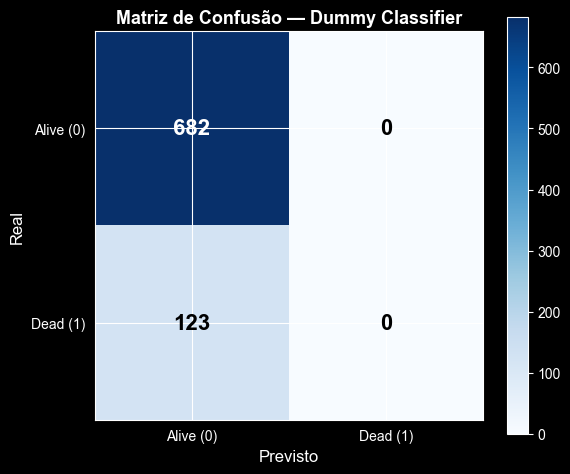

{'TN': np.int64(682),
 'FP': np.int64(0),
 'FN': np.int64(123),
 'TP': np.int64(0)}

In [9]:
def plt_matriz_confusao(y_true, y_pred, nome_modelo='Modelo', salvar=False, caminho=None):
    cm = confusion_matrix(y_true, y_pred)

    fig, ax = plt.subplots(figsize=(6, 5))

    im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
    plt.colorbar(im)

    classes = ['Alive (0)', 'Dead (1)']

    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])

    ax.set_xticklabels(classes)
    ax.set_yticklabels(classes)

    ax.set_xlabel('Previsto', fontsize=12)
    ax.set_ylabel('Real', fontsize=12)

    ax.set_title(
        f'Matriz de Confusão — {nome_modelo}',
        fontsize=13,
        fontweight='bold'
    )

    for i in range(2):
        for j in range(2):

            ax.text(j, i, str(cm[i, j]), ha='center', va='center', fontsize=16, fontweight='bold', color='white' if cm[i, j] > cm.max() / 2 else 'black'
            )

    plt.tight_layout()

    if salvar and caminho is not None:
        plt.savefig(caminho, dpi=150)

    plt.show()

    return {
        "TN": cm[0,0],
        "FP": cm[0,1],
        "FN": cm[1,0],
        "TP": cm[1,1]
    }

plt_matriz_confusao(
    y_test,
    y_pred,
    nome_modelo='Dummy Classifier',
    salvar=True,
    caminho='../assets/charts_images/distributions/cm_dummy.png'
)